<a href="https://colab.research.google.com/github/AhalaAyyalas/MachineLearning/blob/main/ML_Assign16CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1: CNN Explainer Exploration

### Q1) How many Conv layers does the network have? How many filters in each?

--> There were 4 Conv layers with 10 filters in each.

### Q2) Click on a neuron in the first Conv layer. What kind of pattern does it detect? (edges? colors? textures?)

--> It detects edges and simple color patterns as it is still the first Conv layer.

### Q3) Click on a neuron in a deeper layer. Is the pattern simpler or more complex than Layer 1?

--> It detects more complex and higher-level patterns as it the Conv layer is deeper.

### Q4) In your own words, explain what "pooling" does and why it's useful.

--> Pooling is basically a way for a neural network to shrink its data by combining nearby values into a single representative value, so basically it keeps the important information while reducing detail.

### Q5) What is the final prediction, and how confident is the network?

--> In the CNN Explainer, the final prediction is the class (label) with the highest probability at the output layer.

# Task 2:

1) How many out of 18 drawings (3 rounds × 6 each) did the AI guess correctly? (2 points)

-- Out of 18, the AI guessed 13 correctly.

2) Pick one drawing the AI got wrong. Why do you think it failed? (2 points)

-- The AI got the drawing of a frog wrong, because mine looked more like a dog 😀. Also, the drawings of the other users looked very different from mine.

3) How is Quick, Draw!'s neural network similar to the CNN you learned about today? (2 points)

-- Quick, Draw!'s neural network is similar to a CNN because both learn to recognize visual patterns (like edges and shapes) from large datasets. Just as a CNN breaks an image into features and classifies it, Quick, Draw! analyzes your sketch's strokes to identify what object it most likely represents.

# Task 3

In [ ]:
#@title activity 1

# ===========================================
# CNN for MNIST Digit Classification (Keras)
# ===========================================
# Compare this to Week 23's regular neural network!

import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
import time

# Step 1: Load MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Step 2: Prepare data — CNN needs 4D input: (samples, height, width, channels)
# Notice: we DON'T flatten to 784! We keep the 28x28 shape!
x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

# Step 3: Build the CNN
model = keras.Sequential([
    # --- Convolution Block 1 ---
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    #   32 filters, each 3x3 pixels, using ReLU activation
    layers.MaxPooling2D((2, 2)),
    #   Max pooling with 2x2 window — image shrinks from 26x26 to 13x13

    # --- Convolution Block 2 ---
    layers.Conv2D(64, (3, 3), activation="relu"),
    #   64 filters, each 3x3 — finds more complex patterns
        layers.MaxPooling2D((2, 2)),
    #   Shrinks again

    # --- Flatten + Dense Layers (same as Week 23 from here) ---
    layers.Flatten(),
    #   Convert 2D feature maps to 1D list
    layers.Dense(64, activation="relu"),
    #   Regular hidden layer
    layers.Dense(10, activation="softmax")
    #   Output: 10 neurons for digits 0-9
])

# Step 4: Show what we built
model.summary()

# Step 5: Compile and train
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

print("\n Training CNN...")
print("=" * 50)
start = time.time()
model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.1)
cnn_time = time.time() - start

# Step 6: Test
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"\n{'=' * 50}")
print(f"CNN Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Training Time: {cnn_time:.1f}s")

print(f"\nCompare to Week 23:")
print(f"   Regular NN (Keras):     ~97.5%")
print(f"   CNN (this week):        {test_accuracy * 100:.2f}%")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)


 Training CNN...
Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9449 - loss: 0.1800 - val_accuracy: 0.9853 - val_loss: 0.0573
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9832 - loss: 0.0553 - val_accuracy: 0.9875 - val_loss: 0.0408
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9882 - loss: 0.0380 - val_accuracy: 0.9898 - val_loss: 0.0329
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9905 - loss: 0.0287 - val_accuracy: 0.9907 - val_loss: 0.0339
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9928 - loss: 0.0226 - val_accuracy: 0.9892 - val_loss: 0.0431
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9887 - loss: 0.0395

CNN Test Accuracy: 98.87%
Training Time: 24.4s

Compare to Week 23:
   Regular NN (Keras):     ~97.5%
   CNN (this week):        98.87%


In [ ]:
#@title Showdown

# ===========================================
# SHOWDOWN: Regular NN vs CNN vs Random Forest
# ===========================================

import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from tensorflow import keras
from tensorflow.keras import layers
import time

# Load data
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train_flat = x_train.reshape(-1, 784).astype("float32") / 255.0
x_test_flat = x_test.reshape(-1, 784).astype("float32") / 255.0
x_train_cnn = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
x_test_cnn = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0
results = {}

# 1. Random Forest
print("Training Random Forest...")
start = time.time()
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train_flat[:10000], y_train[:10000])
results['Random Forest'] = (accuracy_score(y_test, rf.predict(x_test_flat)), time.time()-start, 'Classic ML')
print(f"   Done! {results['Random Forest'][0]*100:.2f}%")

# 2. Regular NN (scikit-learn)
print("\nTraining Regular NN (scikit-learn)...")
start = time.time()
mlp = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=20, random_state=42, verbose=False)
mlp.fit(x_train_flat, y_train)
results['Regular NN (sklearn)'] = (accuracy_score(y_test, mlp.predict(x_test_flat)), time.time()-start, 'Neural Net')
print(f"   Done! {results['Regular NN (sklearn)'][0]*100:.2f}%")

# 3. Regular NN (Keras)
print("\nTraining Regular NN (Keras)...")
nn = keras.Sequential([
    layers.Dense(128, activation="relu", input_shape=(784,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])
nn.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
start = time.time()
nn.fit(x_train_flat, y_train, epochs=5, batch_size=32, verbose=0)
_, nn_acc = nn.evaluate(x_test_flat, y_test, verbose=0)
results['Regular NN (Keras)'] = (nn_acc, time.time()-start, 'Neural Net')
print(f"   Done! {nn_acc*100:.2f}%")

# 4. CNN (Keras) - THE STAR OF THIS WEEK!
print("\nTraining CNN (Keras)...")
cnn = keras.Sequential([
    layers.Conv2D(32, (3,3), activation="relu", input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])
cnn.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
start = time.time()
cnn.fit(x_train_cnn, y_train, epochs=5, batch_size=64, verbose=0)
_, cnn_acc = cnn.evaluate(x_test_cnn, y_test, verbose=0)
results['CNN (Keras)'] = (cnn_acc, time.time()-start, 'CNN')
print(f"   Done! {cnn_acc*100:.2f}%")
# SCOREBOARD
print("\n" + "=" * 65)
print("FINAL SCOREBOARD - MNIST Digit Classification")
print("=" * 65)
print(f"{'Approach':<25} {'Accuracy':<12} {'Time':<10} {'Type'}")
print("-" * 65)
for name, (acc, t, tp) in sorted(results.items(), key=lambda x: -x[1][0]):
    medal = ">> " if acc == max(v[0] for v in results.values()) else "   "
    print(f"{medal}{name:<23} {acc*100:.2f}%       {t:.1f}s       {tp}")
print("-" * 65)
print("\nNotice how the CNN beats the regular NN - especially on images!")


Training Random Forest...
   Done! 95.03%

Training Regular NN (scikit-learn)...


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   Done! 97.84%

Training Regular NN (Keras)...
   Done! 97.54%

Training CNN (Keras)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   Done! 98.89%

FINAL SCOREBOARD - MNIST Digit Classification
Approach                  Accuracy     Time       Type
-----------------------------------------------------------------
>> CNN (Keras)             98.89%       22.6s       CNN
   Regular NN (sklearn)    97.84%       32.0s       Neural Net
   Regular NN (Keras)      97.54%       28.3s       Neural Net
   Random Forest           95.03%       6.4s       Classic ML
-----------------------------------------------------------------

Notice how the CNN beats the regular NN - especially on images!


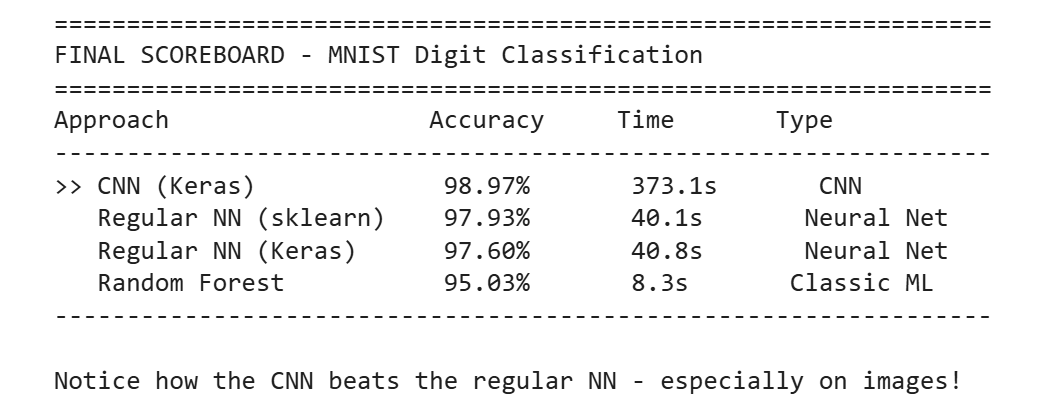

2) How much better is the CNN compared to the regular NN? (percentage difference)

-- CNN is 1% better than NN

3) Try changing the CNN: add a third Conv2D(128, (3,3)) layer. Does accuracy improve?

-- Below is the modified code. And as seen, the accuracy remains unchanged or rather it has decreased.

4) Try changing the number of filters: change 32 to 16. What happens?

-- The accuracy slightly decreases but the training time significantly decreases



In [ ]:
#@title Modified CNN
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
import time

# Load MNIST data (if not already loaded)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Prepare data — CNN needs 4D input: (samples, height, width, channels)
x_train_cnn_modified = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
x_test_cnn_modified = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

# Build the MODIFIED CNN with an additional Conv2D layer
model_modified = keras.Sequential([
    # --- Convolution Block 1 ---
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    # --- Convolution Block 2 ---
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # --- NEW Convolution Block 3 ---
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)), # Adding another pooling layer after the new conv layer

    # --- Flatten + Dense Layers ---
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

# Show what we built
model_modified.summary()

# Compile and train
model_modified.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

print("\nTraining MODIFIED CNN...")
print("=" * 50)
start_modified = time.time()
model_modified.fit(x_train_cnn_modified, y_train, epochs=5, batch_size=64, validation_split=0.1)
cnn_time_modified = time.time() - start_modified

# Test
test_loss_modified, test_accuracy_modified = model_modified.evaluate(x_test_cnn_modified, y_test)
print(f"\n{'=' * 50}")
print(f"MODIFIED CNN Test Accuracy: {test_accuracy_modified * 100:.2f}%")
print(f"Training Time: {cnn_time_modified:.1f}s")

# Compare with original CNN accuracy (from previous cell output)
original_cnn_accuracy = 0.9897 # Based on the last run of cell 'inM9Y7dh4Hon'
print(f"\nOriginal CNN Accuracy: {original_cnn_accuracy * 100:.2f}%")
print(f"Difference in Accuracy: {(test_accuracy_modified - original_cnn_accuracy) * 100:.2f}%")

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,578 (396.79 KB)

 Trainable params: 101,578 (396.79 KB)

 Non-trainable params: 0 (0.00 B)


Training MODIFIED CNN...
Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 47s 54ms/step - accuracy: 0.9238 - loss: 0.2500 - val_accuracy: 0.9758 - val_loss: 0.0775
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 44s 52ms/step - accuracy: 0.9775 - loss: 0.0760 - val_accuracy: 0.9813 - val_loss: 0.0609
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 46s 54ms/step - accuracy: 0.9829 - loss: 0.0555 - val_accuracy: 0.9835 - val_loss: 0.0509
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 81s 53ms/step - accuracy: 0.9856 - loss: 0.0449 - val_accuracy: 0.9840 - val_loss: 0.0465
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 82s 53ms/step - accuracy: 0.9887 - loss: 0.0346 - val_accuracy: 0.9882 - val_loss: 0.0421
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9847 - loss: 0.0486

MODIFIED CNN Test Accuracy: 98.47%
Training Time: 337.6s

Original CNN Accuracy: 98.97%
Difference in Accuracy: -0.50%


# Task 4:

In [ ]:
# ===========================================
# CNN for Fashion-MNIST (Clothing Classification)
# ===========================================
# Same format as MNIST, but much harder!

import numpy as np
from tensorflow import keras
from tensorflow.keras import layers

# Step 1: Load Fashion-MNIST (built into Keras!)
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Class names (Fashion-MNIST uses numbers 0-9 for these categories)
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Step 2: Prepare data
x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

# Step 3: Build a slightly deeper CNN
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),  # Extra conv layer!
        layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

# Step 4: Train
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

print("Training CNN on Fashion-MNIST...")
model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.1, verbose=1)

# Step 5: Test
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"\nFashion-MNIST Accuracy: {test_acc * 100:.2f}%")

# Step 6: Show predictions with class names
predictions = model.predict(x_test[:10])
print("\nFirst 10 predictions:")
for i in range(10):
    pred_class = np.argmax(predictions[i])
    confidence = predictions[i][pred_class] * 100
    actual = y_test[i]
    status = "CORRECT" if pred_class == actual else "WRONG"
    print(f"  [{status}] Predicted: {class_names[pred_class]:12s} | Actual: {class_names[actual]:12s} | Confidence: {confidence:.1f}%")

Training CNN on Fashion-MNIST...
Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 45s 52ms/step - accuracy: 0.7990 - loss: 0.5508 - val_accuracy: 0.8650 - val_loss: 0.3775
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 82s 52ms/step - accuracy: 0.8734 - loss: 0.3498 - val_accuracy: 0.8757 - val_loss: 0.3340
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 44s 52ms/step - accuracy: 0.8919 - loss: 0.2969 - val_accuracy: 0.8902 - val_loss: 0.2945
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 46s 54ms/step - accuracy: 0.8997 - loss: 0.2688 - val_accuracy: 0.8982 - val_loss: 0.2811
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 81s 53ms/step - accuracy: 0.9102 - loss: 0.2445 - val_accuracy: 0.9050 - val_loss: 0.2650
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 89s 61ms/step - accuracy: 0.9161 - loss: 0.2262 - val_accuracy: 0.9052 - val_loss: 0.2592
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 79s 58ms/step - accuracy: 0.9219 - loss: 0.2093 - val_accuracy: 0.9065 - val_loss: 0.2735
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 77s 53ms/step - a